# Algoritmo de Detección de Fuego NOAA/GOES (Fase 1)

Este cuaderno implementa de manera interactiva la **Fase 1** del algoritmo de detección sub-píxel de fuego con datos del sensor ABI (Advanced Baseline Imager) a bordo de los satélites GOES-R, basándose en el documento oficial *Algorithm Theoretical Basis Document (ATBD)*.

En esta fase exploraremos desde la carga y conversión de las temperaturas de brillo hasta la generación de las máscaras de salida que identifican píxeles con potencial fuego.

## 1. Importación de Librerías y Constantes Globales

El ATBD define valores de saturación, valores faltantes y coeficientes específicos del instrumento ABI para las funciones de Planck.

* **FPT (Focal Plane Temperature) Threshold:** Si la temperatura del plano focal excede los 90 K, el algoritmo crea una banda híbrida de onda larga para mitigar problemas.
* **Buffer de Saturación:** Un píxel se considera erróneo si su temperatura excede en 5 K la temperatura de saturación definida por el sistema.

In [1]:
import numpy as np
def obtener_mascara_noaa_colab(timestamp_str: str, region_cfg: dict, satellite: str = "G16") -> np.ndarray:
    """
    Descarga el producto oficial ABI-L2-FDCF (Fire Mask) vía goes2go,
    aplica el recorte geográfico exacto y devuelve la matriz categórica de fuegos.
    """
    dt = pd.to_datetime(timestamp_str)
    print(f"🔍 Buscando Máscara Oficial NOAA (ABI-L2-FDCF) para {timestamp_str}...")
    
    # En L2 no se especifica el parámetro 'bands'
    g = GOES(satellite=satellite, product="ABI-L2-FDCF", domain="F")
    
    files_df = g.nearesttime(dt, return_as="filelist")
    if files_df is None or len(files_df) == 0:
        raise RuntimeError(f"No se encontraron archivos L2 FDC para la fecha {timestamp_str}")
        
    relative_path = files_df.iloc[0]["file"]
    try:
        from goes2go.config import config as g2g_config
        cache_dir = g2g_config.get("default", {}).get("save_dir", os.path.expanduser("~/data"))
    except Exception:
        cache_dir = os.path.expanduser("~/data")
        
    full_path = os.path.join(cache_dir, relative_path)
    
    # Abrimos de forma diferida y recortamos usando tus slices originales
    with xr.open_dataset(full_path, engine="h5netcdf") as ds:
        xs, ys = goes_xy_slices(ds, **region_cfg)
        # La variable estándar del producto FDC de la NOAA es 'Mask'
        mask_noaa = ds.sel(x=xs, y=ys)["Mask"].values.astype(np.int16)
        
    print(f" ✅ Máscara oficial NOAA descargada con éxito. Matriz shape: {mask_noaa.shape}")
    return mask_noaa

In [2]:
from __future__ import annotations

import logging
import os
from typing import Optional

import numpy as np

# Configuración básica de logs para el entorno Colab
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

# ══════════════════════════════════════════════════════════════════════════════
# Constantes globales
# ══════════════════════════════════════════════════════════════════════════════

BR_TEMP_MISS_VAL: float = -999.0   # Valor centinela de temperatura de brillo faltante
SAT_TEMP: float         = 335.0    # Temperatura de saturación del sensor (K)
SAT_BUFF: float         = 5.0      # Buffer de saturación (K)
FPT_THRESHOLD: float    = 90.0     # Umbral de temperatura del plano focal

# Constantes de Planck para cada banda ABI usada
# Basadas en los coeficientes espectrales del ABI (GOES-R PUG L1b Rev 2)
# c1 = 2*h*c^2  [mW / (m^2·sr·cm^-4)]
# c2 = h*c/k    [K·cm]
_ABI_BAND_PARAMS: dict[int, dict[str, float]] = {
    7:  {"fk1": 202526.8, "fk2": 3698.03, "bc1": 0.4759,  "bc2": 0.99810},
    13: {"fk1": 671922.5, "fk2": 1285.62, "bc1": 0.3764,  "bc2": 0.99891},
    14: {"fk1": 620818.5, "fk2": 1216.99, "bc1": 0.3572,  "bc2": 0.99912},
    15: {"fk1": 520364.0, "fk2": 1107.43, "bc1": 0.3011,  "bc2": 0.99933},
}

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Funciones auxiliares de radiometría (Planck)
# ══════════════════════════════════════════════════════════════════════════════

def _rad_from_temp(band: int, temp: np.ndarray | float) -> np.ndarray | float:
    """
    Temperatura de brillo → radianza equivalente para *band*.
    Usa la función de Planck inversa con los coeficientes del ABI.
    """
    p   = _ABI_BAND_PARAMS[band]
    t   = (temp - p["bc1"]) / p["bc2"]
    # Evitar división por cero / overflow en exp
    t   = np.where(t > 0, t, np.nan) if isinstance(t, np.ndarray) else max(t, 1e-6)
    rad = p["fk1"] / (np.exp(p["fk2"] / t) - 1.0)
    return rad

def _temp_from_rad(band: int, rad: np.ndarray | float) -> np.ndarray | float:
    """
    Radianza → temperatura de brillo equivalente para *band*.
    """
    p    = _ABI_BAND_PARAMS[band]
    safe = np.where(rad > 0, rad, np.nan) if isinstance(rad, np.ndarray) else max(rad, 1e-12)
    t    = p["fk2"] / np.log(p["fk1"] / safe + 1.0)
    return p["bc1"] + p["bc2"] * t

def temp_to_rad(src_band: int, dst_band: int, temp: np.ndarray | float) -> np.ndarray | float:
    """
    Dada una temperatura de brillo en src_band, calcula la radianza
    equivalente en dst_band mediante la función de Planck.
    """
    rad_src = _rad_from_temp(src_band, temp)
    if src_band == dst_band:
        return rad_src
    return _rad_from_temp(dst_band, temp)

def rad_to_temp(src_band: int, dst_band: int, rad: np.ndarray | float) -> np.ndarray | float:
    """
    Dada una radianza en src_band, devuelve la temperatura de brillo
    equivalente en dst_band.
    """
    temp_src = _temp_from_rad(src_band, rad)
    if src_band == dst_band:
        return temp_src
    return _temp_from_rad(dst_band, _rad_from_temp(src_band, temp_src))

In [3]:
def _compute_pixel_area(
    range: np.ndarray, #En dónde computar el área
    latitudes: np.ndarray,
    longitudes: np.ndarray,
) -> np.ndarray:
    """
    Pixel area in km² using the 4×4 box great-circle method (ATBD 3.4.2.10).

    Corners at (i±2, j±2), distances divided by 4 before area calculation.
    Heron's formula for the parallelogram.
    """
    L, W = latitudes.shape
    index = np.argwhere(range)

    areas = np.zeros_like(latitudes)

    def _clamp(v, lo, hi):
        return max(lo, min(hi, v))
    
    def great_circle_km(r1, c1, r2, c2):
        lat1 = np.radians(latitudes [r1, c1])
        lat2 = np.radians(latitudes [r2, c2])
        lon1 = np.radians(longitudes[r1, c1])
        lon2 = np.radians(longitudes[r2, c2])
        arg  = (np.sin(lat1)*np.sin(lat2)
                + np.cos(lat1)*np.cos(lat2)*np.cos(abs(lon2-lon1)))
        arg  = np.clip(arg, -1.0, 1.0)
        return 6378.137 * np.arccos(arg)

    for (i,j) in index:
        c = [
            (_clamp(i-2, 0, L-1), _clamp(j-2, 0, W-1)),
            (_clamp(i+2, 0, L-1), _clamp(j-2, 0, W-1)),
            (_clamp(i+2, 0, L-1), _clamp(j+2, 0, W-1)),
            (_clamp(i-2, 0, L-1), _clamp(j+2, 0, W-1)),
        ]

    
        # Sides of the 4×4 box divided by 4
        a = great_circle_km(*c[0], *c[1]) / 4.0   # top-left → bottom-left
        b = great_circle_km(*c[1], *c[2]) / 4.0   # bottom-left → bottom-right
        d = great_circle_km(*c[0], *c[2]) / 4.0   # diagonal (used in Heron)

        # Heron for one triangle × 2 → parallelogram area
        s = (a + b + d) / 2.0
        try:
            area = 2.0 * np.sqrt(max(0.0, s * (s-a) * (s-b) * (s-d)))
        except Exception:
            area = 0.0
        areas[i,j] = area 

    return areas

## 7. Adquisición y Recorte de Datos mediante `goes2go` y visualizacion inicial

En lugar de descargar discos completos (*Full Disk*) en bruto que saturen la memoria de la máquina virtual de Colab, adaptaremos el script operativo del pipeline `downloader.py`. 

Este método utiliza `goes2go` para localizar el archivo en los servidores de la NOAA, lo abre en modo diferido (*lazy*) con `xarray` y realiza un recorte espacial exacto convirtiendo límites de Latitud/Longitud a coordenadas de proyección geoestacionaria ($x, y$).

Definiremos los límites geográficos para **Uruguay** y configuraremos los parámetros para las bandas térmicas 7 (3.9 µm), 13 (10.3 µm) y 14 (11.2 µm).

💡 Sugerencia de mejora para tu PFC / Colab:
En el script original fire_detection.py, estos filtros rápidos se ejecutan dentro de un bucle anidado for i in range(L): for j in range(W): píxel por píxel. En Python, realizar bucles de más de 5000x5000 elementos es extremadamente lento.

Al estructurar esta parte en el Colab usando operaciones vectoriales de NumPy (np.where), el procesamiento de estos descartes iniciales va a pasar de tardar varios minutos a ejecutarse en milisegundos. Esto te va a permitir visualizar máscaras intermedias súper rápido usando plt.imshow().

In [4]:
# Instalar dependencias necesarias para este bloque si no están
#!pip install goes2go pyproj netCDF4 h5netcdf matplotlib

import os
import numpy as np
import pyproj
import xarray as xr
import pandas as pd
from goes2go import GOES
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# 1. Configuraciones de Región (Uruguay) y Productos ABI
# ══════════════════════════════════════════════════════════════════════════════

# Caja de recorte para Uruguay
REGION_URUGUAY = {
    "lat_min": -35.5,
    "lat_max": -30.0,
    "lon_min": -58.5,
    "lon_max": -53.0
}

# Configuraciones de las bandas requeridas por el algoritmo
PRODUCTOS_ABI = { 
    1: {"id": "ABI-L1b-B01", "product": "ABI-L1b-RadF", "band": 1,  "variable": "Rad"},
    2: {"id": "ABI-L1b-B02", "product": "ABI-L1b-RadF", "band": 2,  "variable": "Rad"},
    3: {"id": "ABI-L1b-B03", "product": "ABI-L1b-RadF", "band": 3,  "variable": "Rad"},
    7:  {"id": "ABI-L1b-B07", "product": "ABI-L1b-RadF", "band": 7,  "variable": "Rad"},
    13: {"id": "ABI-L1b-B13", "product": "ABI-L1b-RadF", "band": 13, "variable": "Rad"},
    14: {"id": "ABI-L1b-B14", "product": "ABI-L1b-RadF", "band": 14, "variable": "Rad"},
    15: {"id": "ABI-L1b-B15", "product": "ABI-L1b-RadF", "band": 15, "variable": "Rad"},

}

# ══════════════════════════════════════════════════════════════════════════════
# 2. Funciones de Transformación de Coordenadas (script original)
# ══════════════════════════════════════════════════════════════════════════════

def goes_xy_slices(ds, lat_min, lat_max, lon_min, lon_max):
    """Convierte un bounding box de lat/lon a slices de índices x/y de GOES."""
    proj_info  = ds["goes_imager_projection"]
    lon_origin = float(proj_info.longitude_of_projection_origin)
    H          = float(proj_info.perspective_point_height) + float(proj_info.semi_major_axis)

    crs_goes = pyproj.CRS.from_dict({
        "proj": "geos", "lon_0": lon_origin,
        "h": float(proj_info.perspective_point_height),
        "a": float(proj_info.semi_major_axis),
        "b": float(proj_info.semi_minor_axis),
        "sweep": "x",
    })
    transformer = pyproj.Transformer.from_crs(
        pyproj.CRS.from_epsg(4326), crs_goes, always_xy=True
    )
    px, py = transformer.transform(
        [lon_min, lon_max, lon_min, lon_max],
        [lat_min, lat_min, lat_max, lat_max],
    )
    x_vals, y_vals = ds["x"].values, ds["y"].values
    x_slice = slice(
        float(x_vals[np.argmin(np.abs(x_vals - np.nanmin(px) / H))]),
        float(x_vals[np.argmin(np.abs(x_vals - np.nanmax(px) / H))]),
    )
    y_slice = slice(
        float(y_vals[np.argmin(np.abs(y_vals - np.nanmax(py) / H))]),
        float(y_vals[np.argmin(np.abs(y_vals - np.nanmin(py) / H))]),
    )
    return x_slice, y_slice


# ══════════════════════════════════════════════════════════════════════════════
# 3. Función Modular de Descarga y Extracción de Radianzas + Temp de Brillo
# ══════════════════════════════════════════════════════════════════════════════

import os
import pandas as pd
import numpy as np
import xarray as xr
from goes2go import GOES
import time

def obtener_datos_banda_colab(timestamp_str: str, banda: int, region_cfg: dict, satellite: str = "G19") -> tuple[np.ndarray, np.ndarray]:
    """
    Descarga vía goes2go para GOES-19 por defecto, abre de forma lazy, 
    recorta sobre Uruguay y calcula la Temperatura de Brillo.
    """
    dt = pd.to_datetime(timestamp_str)
    p_cfg = PRODUCTOS_ABI[banda]
    
    print(f"🔍 [GOES-19] Buscando {p_cfg['id']} para la fecha {timestamp_str}...")
    
    # Inicialización limpia para GOES-19
    g = GOES(satellite=satellite, product=p_cfg["product"], domain="F", bands=p_cfg["band"])
    
    #print(g.latest())
    #print("GOES creado")

    files_df = g.nearesttime(dt, return_as="filelist")

    #print("Luego de nearesttime")

    if files_df is None or len(files_df) == 0:
        raise RuntimeError(f"No se encontraron archivos en AWS para GOES-19, banda {banda} en {timestamp_str}")
    
    
    relative_path = files_df.iloc[0]["file"]
    try:
        from goes2go.config import config as g2g_config
        cache_dir = g2g_config.get("default", {}).get("save_dir", os.path.expanduser("~/data"))
    except Exception:
        cache_dir = os.path.expanduser("~/data")
        
    full_path = os.path.join(cache_dir, relative_path)
    
    with xr.open_dataset(full_path, engine="h5netcdf") as ds:
        xs, ys = goes_xy_slices(ds, **region_cfg)
        ds_cropped = ds.sel(x=xs, y=ys)
        
        rad = ds_cropped[p_cfg["variable"]].values.astype(np.float32)
        
        # Constantes escalares extraídas de forma segura con .item()
        fk1 = float(ds_cropped['planck_fk1'].item())
        fk2 = float(ds_cropped['planck_fk2'].item())
        bc1 = float(ds_cropped['planck_bc1'].item())
        bc2 = float(ds_cropped['planck_bc2'].item())
        
        rad_safe = np.where(rad > 0, rad, np.nan)
        b_temp = (fk2 / np.log((fk1 / rad_safe) + 1.0) - bc1) / bc2
        b_temp = np.where(np.isnan(b_temp), -999.0, b_temp)
        
    print(f" ✅ GOES-19 B{banda:02d} descargada y recortada. Shape: {rad.shape}")
    return b_temp.astype(np.float32), rad


def obtener_mascara_noaa_colab(timestamp_str: str, region_cfg: dict, satellite: str = "G19") -> np.ndarray:
    """
    Descarga el producto oficial de fuegos ABI-L2-FDCF para GOES-19,
    aplica el recorte geográfico exacto y devuelve la matriz Mask.
    """
    dt = pd.to_datetime(timestamp_str)
    print(f"🔍 [GOES-19] Buscando Máscara Oficial NOAA (ABI-L2-FDCF) para {timestamp_str}...")
    
    g = GOES(satellite=satellite, product="ABI-L2-FDCF", domain="F")
    
    files_df = g.nearesttime(dt, return_as="filelist")
    if files_df is None or len(files_df) == 0:
        raise RuntimeError(f"No se encontraron archivos L2 FDC en GOES-19 para la fecha {timestamp_str}")
        
    relative_path = files_df.iloc[0]["file"]
    try:
        from goes2go.config import config as g2g_config
        cache_dir = g2g_config.get("default", {}).get("save_dir", os.path.expanduser("~/data"))
    except Exception:
        cache_dir = os.path.expanduser("~/data")
        
    full_path = os.path.join(cache_dir, relative_path)
    
    with xr.open_dataset(full_path, engine="h5netcdf") as ds:
        xs, ys = goes_xy_slices(ds, **region_cfg)
        mask_noaa = ds.sel(x=xs, y=ys)["Mask"].values.astype(np.int16)
        
    print(f" ✅ Máscara oficial GOES-19 descargada con éxito. Shape: {mask_noaa.shape}")
    return mask_noaa

In [ ]:
# Definimos el instante de tiempo real de prueba aportado
fecha_test = "2025-09-26 15:00"

# 1. Descarga de bandas L1b para tu algoritmo
bTemp7_uy, rad7_uy   = obtener_datos_banda_colab(fecha_test, 7, REGION_URUGUAY)
bTemp13_uy, rad13_uy = obtener_datos_banda_colab(fecha_test, 13, REGION_URUGUAY)
bTemp14_uy, rad14_uy = obtener_datos_banda_colab(fecha_test, 14, REGION_URUGUAY)
bTemp15_uy, rad15_uy = obtener_datos_banda_colab(fecha_test, 15, REGION_URUGUAY)
bTemp2_uy, rad2_uy = obtener_datos_banda_colab(fecha_test,2,REGION_URUGUAY)

# 2. Descarga de la máscara oficial precalculada de la NOAA (L2)
mascara_noaa_uy = obtener_mascara_noaa_colab(fecha_test, REGION_URUGUAY)

# ══════════════════════════════════════════════════════════════════════════════
# Ejecución de las funciones algorítmicas de la Fase 1
# ══════════════════════════════════════════════════════════════════════════════
ang_cenital_sol_uy = np.full_like(bTemp7_uy, 30.0)
ang_resp_sol_uy    = np.full_like(bTemp7_uy, 45.0)

refl_uy, _, _ = preprocesar_imagenes_abi(
    bTemp7=bTemp7_uy, rad7=rad7_uy,
    bTemp13=bTemp13_uy, rad13=rad13_uy,
    bTemp14=bTemp14_uy, rad14=rad14_uy,
    refl2=None,
    ang_cenital_sol=ang_cenital_sol_uy,
    FPT=85.0
)

mascara_fuego_uy = aplicar_filtros_iniciales(
    bTemp7=bTemp7_uy, rad7=rad7_uy,
    bTemp14=bTemp14_uy, rad14=rad14_uy,
    ang_cenital_sol=ang_cenital_sol_uy,
    ang_resp_sol=ang_resp_sol_uy
)

# ══════════════════════════════════════════════════════════════════════════════
# Visualización interactiva en Colab: 3 Paneles alineados
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(1, 3, figsize=(22, 6))

# Panel 1: Infrarrojo de Onda Corta
im1 = ax[0].imshow(bTemp7_uy, cmap='inferno', vmin=270, vmax=340)
ax[0].set_title(f"Banda 7 (3.9 µm) - Kelvin\nUruguay {fecha_test} UTC")
fig.colorbar(im1, ax=ax[0], label="Kelvin (K)")

# Panel 2: Tu indicador de anomalía térmica de la Fase 1
im2 = ax[1].imshow(refl_uy, cmap='bwr', vmin=-5, vmax=5)
ax[1].set_title("Tu Algoritmo Fase 1\nAnomalía Térmica ΔL (B7 - B14)")
fig.colorbar(im2, ax=ax[1], label="Diferencia de Radianza")

# Panel 3: Producto Operativo L2 de la NOAA
# Usamos 'tab20' o 'viridis' para mapear los códigos numéricos categóricos
im3 = ax[2].imshow(mascara_noaa_uy==100, cmap='tab20')
ax[2].set_title("Máscara Oficial NOAA\nProducto ABI-L2-FDCF (Mask)")
fig.colorbar(im3, ax=ax[2], label="Códigos de Píxel (Categorías NOAA)")



plt.tight_layout()
plt.show()

🔍 [GOES-19] Buscando ABI-L1b-B07 para la fecha 2025-09-26 15:00...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF].
 ✅ GOES-19 B07 descargada y recortada. Shape: (203, 246)
🔍 [GOES-19] Buscando ABI-L1b-B13 para la fecha 2025-09-26 15:00...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF].
 ✅ GOES-19 B13 descargada y recortada. Shape: (203, 246)
🔍 [GOES-19] Buscando ABI-L1b-B14 para la fecha 2025-09-26 15:00...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF].
 ✅ GOES-19 B14 descargada y recortada. Shape: (203, 246)
🔍 [GOES-19] Buscando ABI-L1b-B15 para la fecha 2025-09-26 15:00...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF].
 ✅ GOES-19 B15 descargada y recortada. Shape: (203, 246)
🔍 [GOES-19] Buscando ABI-L1b-B02 para la fecha 2025-09-26 15:00...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF].
 ✅ GOES-19 B02 de

FileNotFoundError: noaa-goes16/ABI-L2-FDCF/2025/269/14

In [5]:
fecha_test = "2025-09-26 12:00"
bTemp2_uy, rad2_uy = obtener_datos_banda_colab(fecha_test,2,REGION_URUGUAY)

🔍 [GOES-19] Buscando ABI-L1b-B02 para la fecha 2025-09-26 12:00...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF].
 ✅ GOES-19 B02 descargada y recortada. Shape: (811, 980)


In [13]:
print(np.max(rad2_uy))
print(np.min(rad2_uy))
print(np.max(bTemp2_uy))
print(np.min(bTemp2_uy))

229.33447
8.891085
-999.0
-999.0


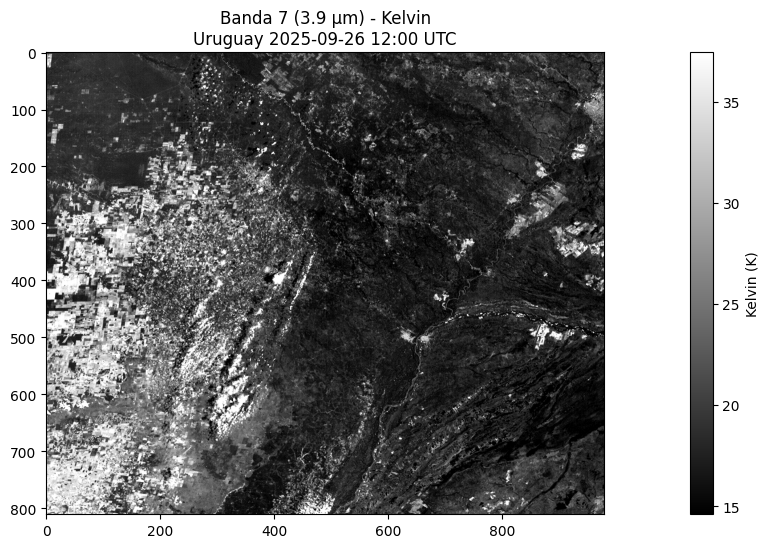

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(22, 6))

vmin = np.percentile(rad2_uy, 2)
vmax = np.percentile(rad2_uy, 98)

# Panel 1: Infrarrojo de Onda Corta
im1 = ax.imshow(rad2_uy, cmap='gray', vmin=vmin, vmax=vmax)
ax.set_title(f"Banda 7 (3.9 µm) - Kelvin\nUruguay {fecha_test} UTC")
fig.colorbar(im1, ax=ax, label="Kelvin (K)")

In [ ]:
!pip install torch
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class FireCNN(nn.Module):
    def __init__(self,n_channels = 6):
        super().__init__()

        self.conv1 = nn.Conv2d(n_channels,16,kernel_size=3,padding=1)
        self.conv2 = nn.Conv2d(16,32,kernel_size=3,padding=1)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(64*16*16,128)
        self.fc2 = nn.Linear(128,1)
        
        self.dropout = nn.Dropout(0.3)
    def forward(self, x ):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))

        x = torch.flatten(x, start_dim=1)

        x = self.dropout(F.relu(self.fc1(x)))

        x = self.fc2(x)

        return x

In [ ]:
model = FireCNN(n_channels = 2)

print(model)

batch_size = 8

X = torch.randn(batch_size, 6, 64, 64)

y = torch.randint(0, 2, (batch_size, 1)).float()

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
optimizer.zero_grad()

pred = model(X)

loss = criterion(pred, y)

loss.backward()

optimizer.step()

print(loss.item())

In [23]:
fecha_test = "2025-09-26"
hora_ini = "12:00"
hora_fin = "14:00"
fecha_ini = fecha_test + " " + hora_ini 
fecha_fin = fecha_test + " " + hora_fin

In [22]:
time_step = 10 #En minutos
#Tomar fechas cada time_step minutos
fechas = pd.date_range(
    start=fecha_ini,
    end=fecha_fin,
    freq=f"{time_step}min"
)
print(fechas)

DatetimeIndex(['2025-09-26 12:00:00', '2025-09-26 12:10:00',
               '2025-09-26 12:20:00', '2025-09-26 12:30:00',
               '2025-09-26 12:40:00', '2025-09-26 12:50:00',
               '2025-09-26 13:00:00'],
              dtype='datetime64[us]', freq='10min')


Obtener bandas 7 y 14

In [24]:
band7 = []
band14 = []
for f in fechas:
    bTemp7_uy, rad7_uy   = obtener_datos_banda_colab(fecha_test, 7, REGION_URUGUAY)
    bTemp14_uy, rad14_uy = obtener_datos_banda_colab(fecha_test, 14, REGION_URUGUAY)
    band7.append(bTemp7_uy)
    band14.append(bTemp14_uy)
    
print(np.array(band7).shape)

🔍 [GOES-19] Buscando ABI-L1b-B07 para la fecha 2025-09-26...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF].
 ✅ GOES-19 B07 descargada y recortada. Shape: (203, 246)
🔍 [GOES-19] Buscando ABI-L1b-B14 para la fecha 2025-09-26...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF].
 ✅ GOES-19 B14 descargada y recortada. Shape: (203, 246)
🔍 [GOES-19] Buscando ABI-L1b-B07 para la fecha 2025-09-26...
 👮🏻‍♂️ File already exists. Do not overwrite: C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF\2025\269\00\OR_ABI-L1b-RadF-M6C07_G19_s20252690000190_e20252690009510_c20252690009556.nc
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF].
 ✅ GOES-19 B07 descargada y recortada. Shape: (203, 246)
🔍 [GOES-19] Buscando ABI-L1b-B14 para la fecha 2025-09-26...
 👮🏻‍♂️ File already exists. Do not overwrite: C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF\2025\269\00\OR_ABI-L1b-RadF-M6C14_G19_s20252690000190_e2025269

Obtener fire hotspots

In [26]:
fire_masks = []
for f in fechas:
    mascara_noaa_uy = obtener_mascara_noaa_colab(f, REGION_URUGUAY)
    #Quedarse solo con los codigos relevantes (por ej los de incendios)
    fire_masks.append(mascara_noaa_uy)


🔍 [GOES-19] Buscando Máscara Oficial NOAA (ABI-L2-FDCF) para 2025-09-26 12:00:00...
 👮🏻‍♂️ File already exists. Do not overwrite: C:\Users\pedro\data\noaa-goes19\ABI-L2-FDCF\2025\269\12\OR_ABI-L2-FDCF-M6_G19_s20252691200192_e20252691209501_c20252691210028.nc
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L2-FDCF].
 ✅ Máscara oficial GOES-19 descargada con éxito. Shape: (203, 246)
🔍 [GOES-19] Buscando Máscara Oficial NOAA (ABI-L2-FDCF) para 2025-09-26 12:10:00...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L2-FDCF].
 ✅ Máscara oficial GOES-19 descargada con éxito. Shape: (203, 246)
🔍 [GOES-19] Buscando Máscara Oficial NOAA (ABI-L2-FDCF) para 2025-09-26 12:20:00...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L2-FDCF].
 ✅ Máscara oficial GOES-19 descargada con éxito. Shape: (203, 246)
🔍 [GOES-19] Buscando Máscara Oficial NOAA (ABI-L2-FDCF) para 2025-09-26 12:30:00...
📦 Finished downloading [1] files to [C:

# Preprocesamiento

Armar "imágenes multiespectrales" (nada más poner todos los canales usados en un mismo array)

In [28]:
tile_size = 128 #Tamaño de los parches
multispectral_imgs = []
for i in range(len(fechas)):
    img = np.stack([band7[i],band14[i]])
    multispectral_imgs.append(img)

print(np.array(multispectral_imgs).shape)

(7, 2, 203, 246)


Dividir las imágenes en parches

In [29]:
def get_patches(img: np.ndarray, patch_size = 64, stride = 32):
    ''' 
    Divide la imagen de entrada en parches de tamaño patch_size x patch_size.
    '''
    patches = []; coords = []
    H,W = img.shape 
    for y in range(0,H-patch_size+1,stride):
        for x in range(0,W-patch_size+1,stride):
            patch = img[y:y+patch_size,x:x+patch_size]
            patches.append(patch)
            coords.append((y,x))
    return patches, coords

In [39]:
fire_codes = (13,14,15)
def get_labels(coords,fire_mask,patch_size = 64):
    labels = []
    for y,x in coords:
        patch_fire = fire_mask[y:y+patch_size,x:x+patch_size]
        #label = np.any(patch_fire in fire_codes) 
        labels.append(patch_fire)
    return labels

In [32]:
patches, coords = get_patches(band7[0])
print(len(patches))

30


In [ ]:
n_patches = len(patches)
fig, ax = plt.subplots(1, 5, figsize=(22, 6))
for i in range(5):
    p = patches[i]
    vmin = np.percentile(p, 2)
    vmax = np.percentile(p, 98)

    # Panel 1: Infrarrojo de Onda Corta
    im1 = ax[i].imshow(p, cmap='inferno', vmin=vmin, vmax=vmax)
    ax[i].set_title(f"Banda 7 (3.9 µm) - Kelvin\nUruguay {fecha_test} UTC")
    fig.colorbar(im1, ax=ax[i], label="Kelvin (K)")

Armar una secuencia temporal de imágenes para los parches

In [ ]:
def get_patch_sequence(frames,y,x,patch_size=64):
    seq = []
    for frame in frames:
        patch = frame[y:y+patch_size,x:x+patch_size]
        seq.append(patch)
    return seq

# Creación de dataset

In [ ]:
n_bands  = 2 #Cantidad de bandas
all_patches7 = []
all_patches14 = []
all_patches_fire = []

for i in range(len(fechas)):
    #Divido cada banda en parches
    patches7, coords = get_patches(band7[i])
    patches14, coords = get_patches(band14[i])
    labels = get_labels(coords,fire_masks[i])
    all_patches7.append(patches7) ; all_patches14.append(patches14) ; all_patches_fire.append(labels)

#Cada columna del array (TxN) es una secuencia
all_patches7 = np.stack(all_patches7, axis=0)
all_patches14 = np.stack(all_patches14, axis=0)
all_patches_fire = np.stack(all_patches_fire, axis=0)

#Deberia ser (n_t,n_p,h,w) donde n_t es la cant de tiempos, n_p la cant de parches por imagen y hxw tamaño de parche
print(all_patches7.shape)
print(all_patches14.shape)
print(all_patches_fire.shape)

(7, 30, 64, 64)
(7, 30, 64, 64)
(7, 30, 64, 64)


Construyo una serie temporal para cada parche

In [ ]:
n_patches = all_patches7.shape[1] #Cantidad de fechas
data_points = []
for i in range(n_patches):
    seq7 = all_patches7[:,i,:,:]
    seq14 = all_patches14[:,i,:,:]
    seq_fire = all_patches_fire[:,i,:,:]
    data_points.append((seq7,seq14,seq_fire))

# Paper modelo regresion

Ignorar por ahora...

In [7]:
def obtener_datos_reflectancia_colab(timestamp_str: str, banda: int, region_cfg: dict, satellite: str = "G19") -> tuple[np.ndarray, np.ndarray]:

    dt = pd.to_datetime(timestamp_str)
    p_cfg = PRODUCTOS_ABI[banda]
    
    print(f"🔍 [GOES-19] Buscando {p_cfg['id']} para la fecha {timestamp_str}...")
    
    # Inicialización limpia para GOES-19
    g = GOES(satellite=satellite, product="ABI-L2-BRFF", domain="F", bands=p_cfg["band"])
    
    #print(g.latest())
    #print("GOES creado")

    files_df = g.nearesttime(dt, return_as="filelist")

    #print("Luego de nearesttime")

    if files_df is None or len(files_df) == 0:
        raise RuntimeError(f"No se encontraron archivos en AWS para GOES-19, banda {banda} en {timestamp_str}")
    
    
    relative_path = files_df.iloc[0]["file"]
    try:
        from goes2go.config import config as g2g_config
        cache_dir = g2g_config.get("default", {}).get("save_dir", os.path.expanduser("~/data"))
    except Exception:
        cache_dir = os.path.expanduser("~/data")
        
    full_path = os.path.join(cache_dir, relative_path)
    
    with xr.open_dataset(full_path, engine="h5netcdf") as ds:
        xs, ys = goes_xy_slices(ds, **region_cfg)
        ds_cropped = ds.sel(x=xs, y=ys)
        
        refl = ds_cropped[p_cfg["variable"]].values.astype(np.float32)
        
    
        
    print(f" ✅ GOES-19 B{banda:02d} descargada y recortada. Shape: {refl.shape}")
    return refl.astype(np.float32)

In [ ]:
import pandas as pd
from scipy.stats import linregress

In [ ]:
ndvi = (refl2-refl3)/(refl2+refl3)#NDVI (Normalized Difference Vegetation Index)
ndii7 = (refl3-refl6)/(refl3+refl6) #NDII7 (Normalized Difference Infrared Index)
lst = ... #ABI-L2-LSTC, Land surface temperature

In [ ]:

df = pd.DataFrame({
    "ndvi": ndvi.values.ravel(),
    "temp": temp.values.ravel()
})
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna() #Elimino filas con nan

#df = df[(df["ndvi"] > 0) & (df["ndvi"] < 1)]

df["bin"] = pd.cut(df["ndvi"], bins=50) #Divido eje ndvi en 50 bins

dry = df.groupby("bin")["temp"].quantile(0.98) #Busco pixeles mas calientes en cada bin
wet = df.groupby("bin")["temp"].quantile(0.02) #Busco pixeles mas frios en cada bin

centers = np.array([ #Centros de cada bin
    interval.mid
    for interval in dry.index.categories
])
valid = ~(np.isnan(dry.values) | np.isnan(wet.values)) #Elimino bins vacios
x = centers[valid]
dry_y = dry.values[valid]
wet_y = wet.values[valid]


dry_slope, dry_intercept, *_ = linregress(x, dry_y) #Ajusto valores mediante regresion lineal
tdry = dry_intercept + dry_slope * ndvi


wet_constant = np.nanmean(wet_y)



tvdi = (lst - wet_constant) / (tdry - wet_constant)
tvdi = tvdi.clip(min=0, max=1)

